### Setup

In [1]:
!pip install cartopy


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\silvi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path

# --- Paths ---
PROJECT_ROOT = Path.cwd().parent
OUTPUT_DIR   = PROJECT_ROOT / "outputs"         

# --- Load posterior samples (post burn-in) ---
G0_samp     = np.load(OUTPUT_DIR / "G0_samples.npy")        # (ny, ny, K)
GPhi_samp   = np.load(OUTPUT_DIR / "G_Phi_samples.npy")     # (ny, ny, n_lags, K)
Phi_samp    = np.load(OUTPUT_DIR / "Phi_samples.npy")       # (ny, ny, n_lags, K)
Sigma_samp  = np.load(OUTPUT_DIR / "Sigma_u_samples.npy")   # (ny, ny, K)
G0_mask     = np.load(OUTPUT_DIR / "G0_expanded.npy")       # physical-network mask

ny, _, K        = G0_samp.shape
n_lags          = GPhi_samp.shape[2]
SELECTED_LAGS   = [1, 2, 3, 7]                             

# --- Variable labels: countries x {Price, Demand} ---
COUNTRIES = ["AT", "BE", "BG", "CH", "CZ", "DE", "DK", "EE", "ES","FI","FR", "GR",
          "HR", "HU", "IE", "IT", "LT", "LV", "ME", "NL", "NO", "PL", "PT",
          "RO", "RS", "SE", "SI", "SK"]
VAR_TYPES = ["Price", "Demand"]                                          
LABELS = [f"{c}_{v}" for c in COUNTRIES for v in VAR_TYPES]
assert len(LABELS) == ny, f"Labels mismatch: {len(LABELS)} vs ny={ny}"

print(f"Loaded: ny={ny}, n_lags={n_lags}, K={K} draws")
print(f"Lags: {SELECTED_LAGS}")

Loaded: ny=56, n_lags=4, K=10000 draws
Lags: [1, 2, 3, 7]


# Posterior Inclusion Probabilities and MPM
Look at the posterior probability that an edge exists. For sensitivity analysis we have three thresholds: 0.5, 0.7, 0.9

 threshold  G0_edges  GPhi_lag1  GPhi_lag2  GPhi_lag3  GPhi_lag7  GPhi_total
       0.5       117       1606       1476       1546       1818        6446
       0.7        43        887        675        771       1110        3443
       0.9        11        480        283        346        611        1720


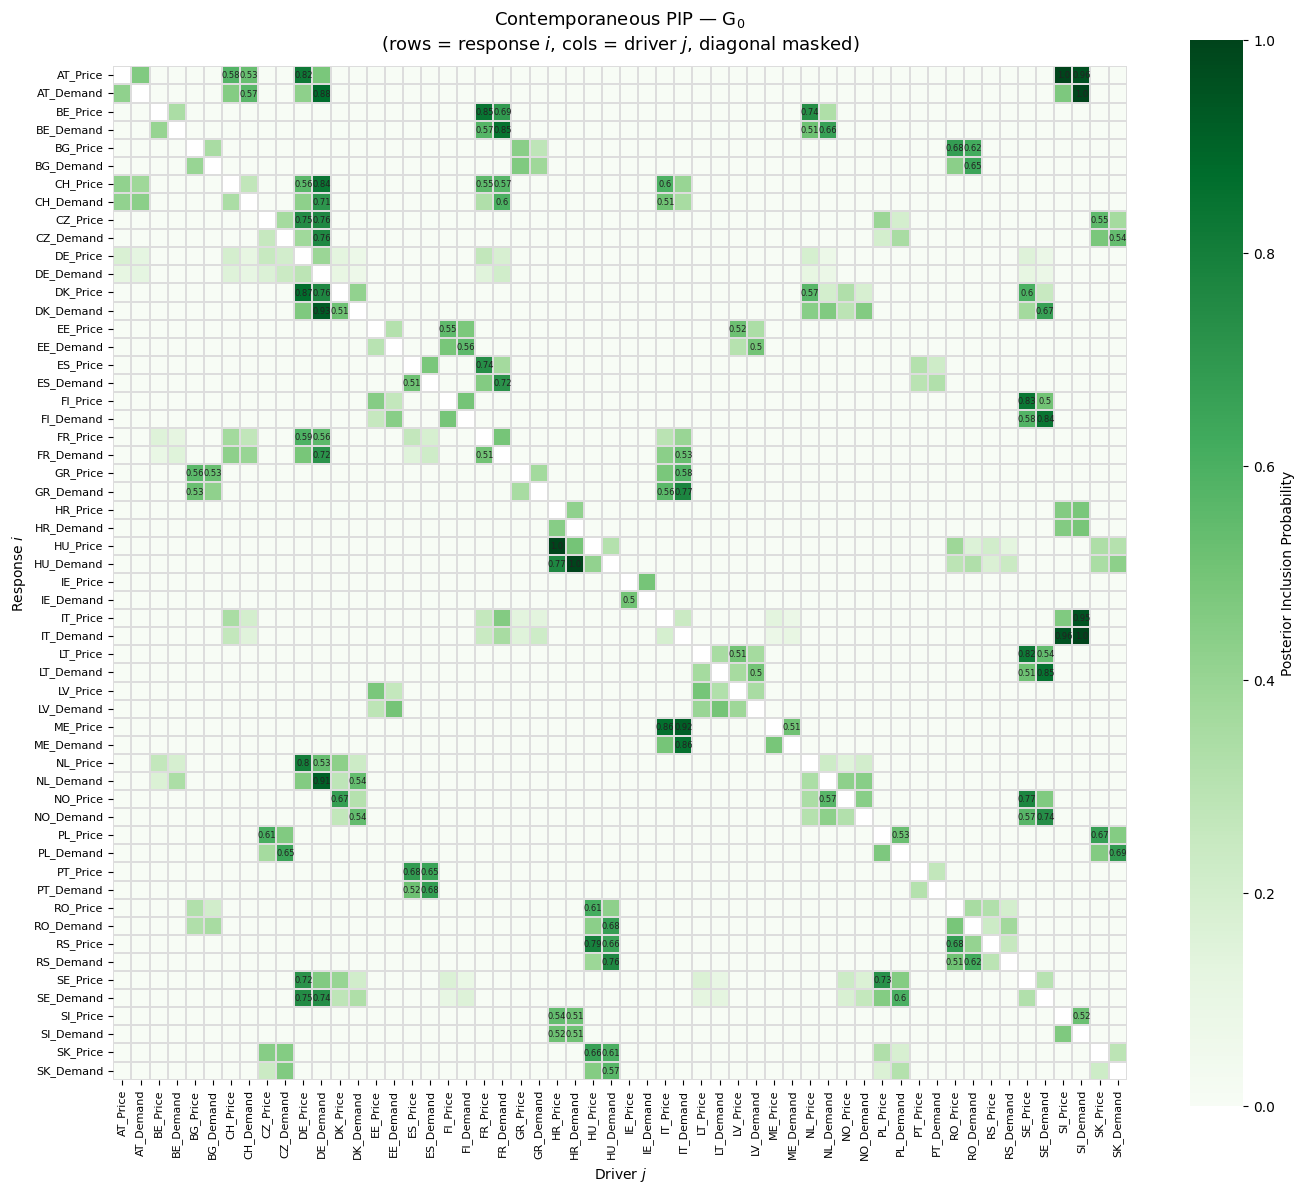

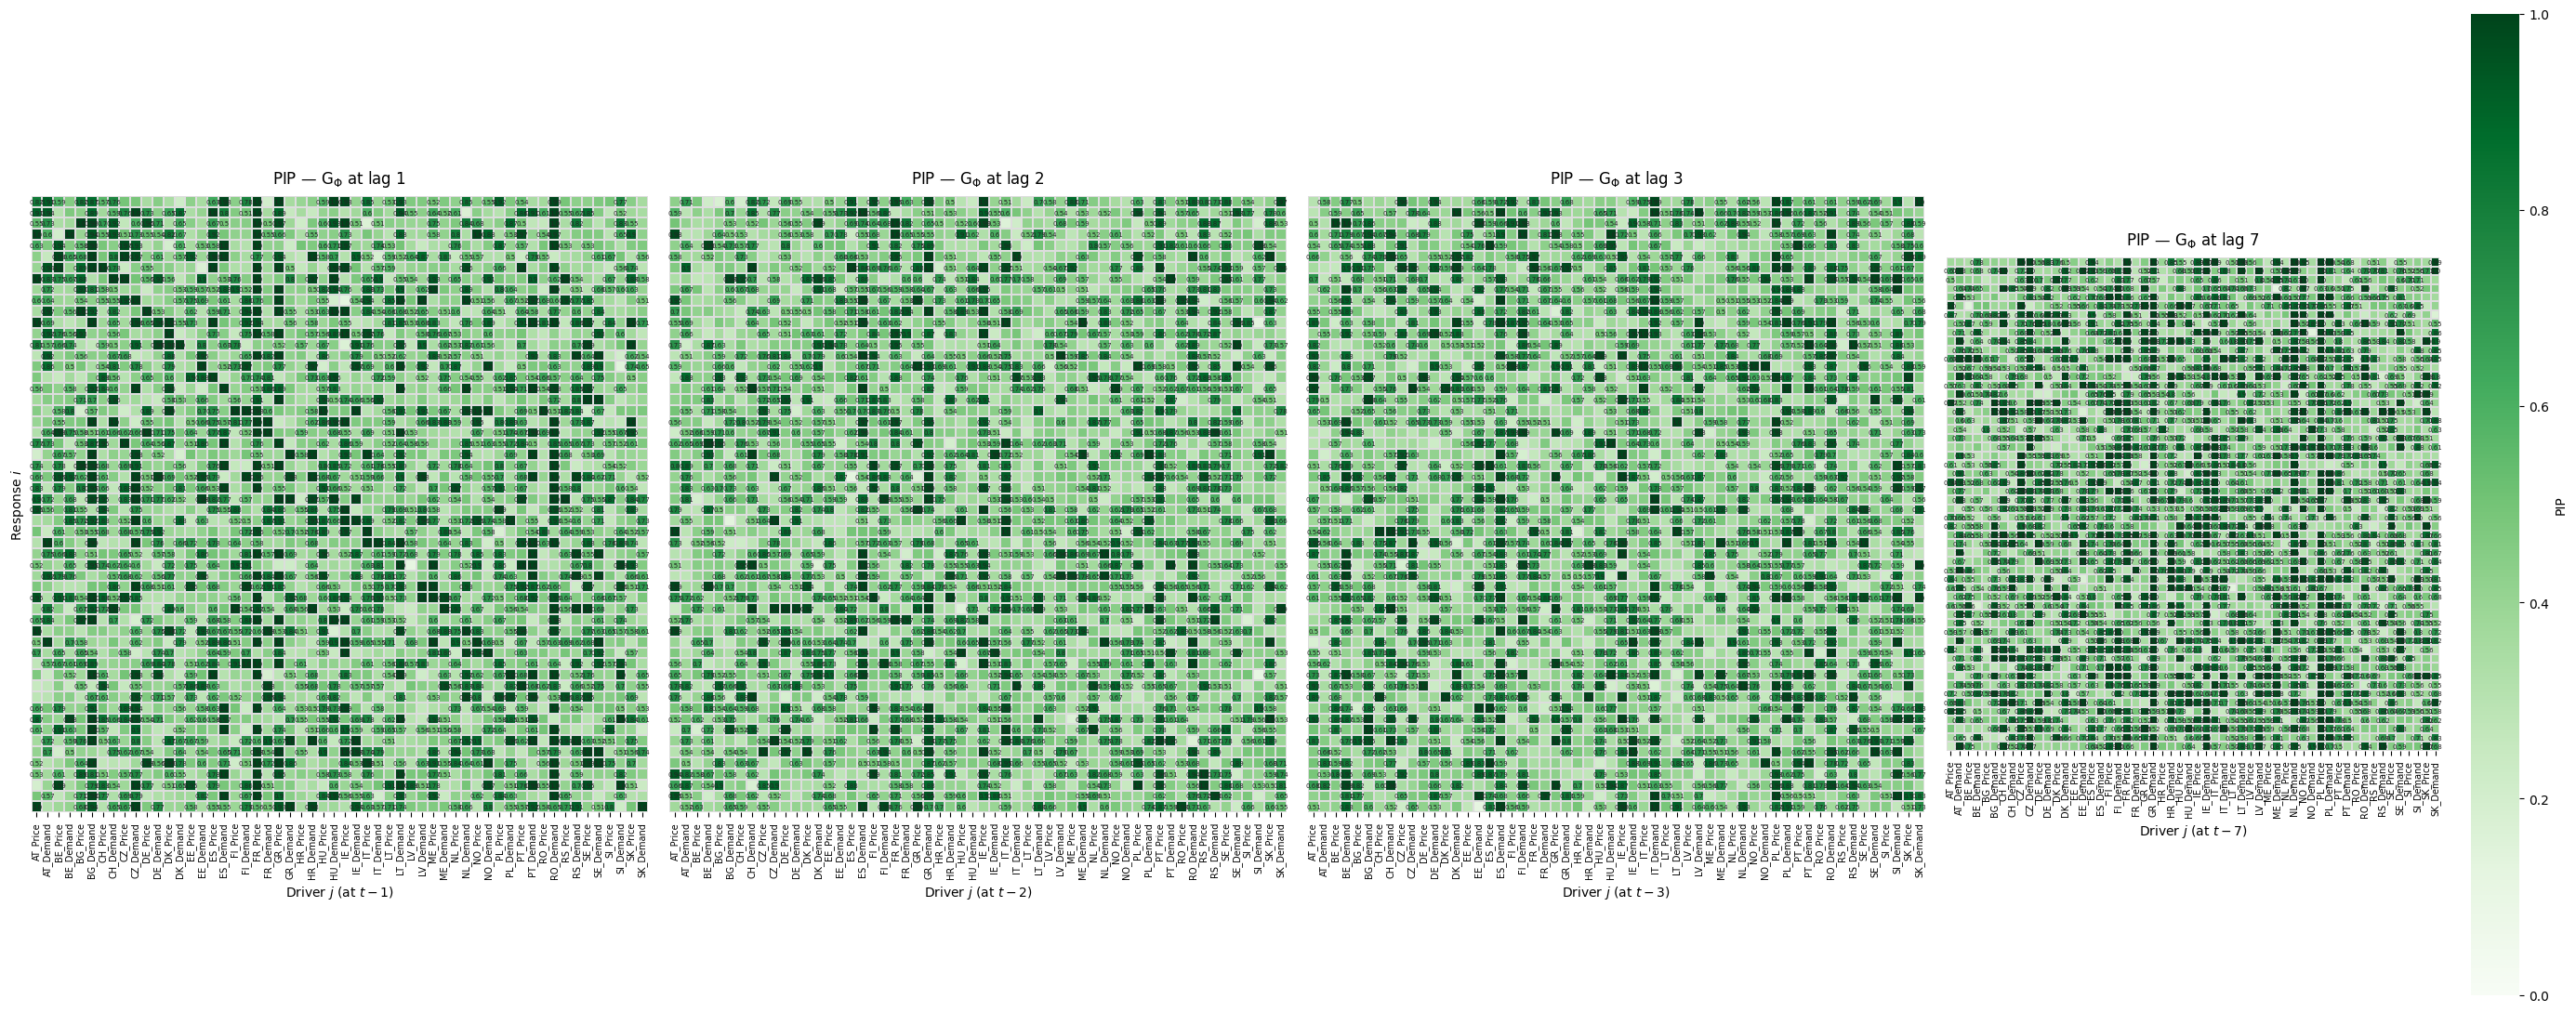

In [3]:
# --- PIPs: average the binary samples over MCMC draws ---
PIP_G0   = G0_samp.mean(axis=2)                # (ny, ny)
PIP_GPhi = GPhi_samp.mean(axis=3)              # (ny, ny, n_lags)

# --- Median Probability Models at multiple thresholds ---
THRESHOLDS = [0.5, 0.7, 0.9]
MPM_G0   = {t: (PIP_G0   > t).astype(int) for t in THRESHOLDS}
MPM_GPhi = {t: (PIP_GPhi > t).astype(int) for t in THRESHOLDS}

# --- Summary: how many edges survive at each threshold ---
summary = []
for t in THRESHOLDS:
    summary.append({
        "threshold": t,
        "G0_edges":  int(MPM_G0[t].sum()),
        **{f"GPhi_lag{SELECTED_LAGS[l]}": int(MPM_GPhi[t][:, :, l].sum())
           for l in range(n_lags)},
        "GPhi_total": int(MPM_GPhi[t].sum()),
    })
mpm_table = pd.DataFrame(summary)
print(mpm_table.to_string(index=False))

def _annot_matrix(pip_matrix, threshold=0.5, decimals=2):
    """
    Return a string matrix the same shape as pip_matrix where
    cells with PIP > threshold contain the rounded value as text and
    all other cells contain an empty string.
    """
    annot = np.where(
        pip_matrix > threshold,
        np.round(pip_matrix, decimals).astype(str),
        "",
    )
    return annot
 
 
fig, ax = plt.subplots(figsize=(14, 12))
 
# Mask the diagonal so that self-loops do not dominate the picture
mask_diag = np.eye(PIP_G0.shape[0], dtype=bool)
 
sns.heatmap(
    PIP_G0,
    cmap="Greens", vmin=0, vmax=1,
    mask=mask_diag,                                # hide diagonal
    xticklabels=LABELS, yticklabels=LABELS,
    cbar_kws={"label": "Posterior Inclusion Probability"},
    ax=ax,
    annot=_annot_matrix(PIP_G0, threshold=0.5),    # numeric values only above 0.5
    fmt="",                                         # we already pass strings
    annot_kws={"size": 6, "color": "#222222"},
    linewidths=0.25, linecolor="#dddddd",
    square=True,
)
ax.set_title(
    "Contemporaneous PIP — G$_0$\n"
    "(rows = response $i$, cols = driver $j$, diagonal masked)",
    fontsize=13, pad=12,
)
ax.set_xlabel("Driver $j$"); ax.set_ylabel("Response $i$")
ax.tick_params(axis="x", labelrotation=90, labelsize=8)
ax.tick_params(axis="y", labelrotation=0,  labelsize=8)
plt.tight_layout()
plt.show()
 
 
fig, axes = plt.subplots(
    1, n_lags,
    figsize=(7 * n_lags, 11),
    sharey=True,
)
if n_lags == 1:
    axes = [axes]
 
for l, ax in enumerate(axes):
    pip_l = PIP_GPhi[:, :, l]
    sns.heatmap(
        pip_l,
        cmap="Greens", vmin=0, vmax=1,
        xticklabels=LABELS,
        yticklabels=LABELS if l == 0 else False,
        cbar=(l == n_lags - 1),
        cbar_kws={"label": "PIP"} if l == n_lags - 1 else None,
        ax=ax,
        annot=_annot_matrix(pip_l, threshold=0.5),
        fmt="",
        annot_kws={"size": 5, "color": "#222222"},
        linewidths=0.2, linecolor="#dddddd",
        square=True,
    )
    ax.set_title(f"PIP — G$_\\Phi$ at lag {SELECTED_LAGS[l]}",
                 fontsize=12, pad=10)
    ax.set_xlabel(f"Driver $j$ (at $t-{SELECTED_LAGS[l]}$)")
    if l == 0:
        ax.set_ylabel("Response $i$")
    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
    ax.tick_params(axis="y", labelrotation=0,  labelsize=7)
 
plt.tight_layout()
plt.show()


# Economic interpretation of $G_0$

In [4]:
def edge_list(M_bin, PIP, labels, min_pip=0.5):
    """
    Return an edge dataframe sorted by PIP, descending.
    Convention: row = response i, col = driver j  ->  edge j -> i
    """
    rows = []
    ny = M_bin.shape[0] 
    for i in range(ny):
        for j in range(ny):
            if M_bin[i, j] == 1 and i != j:
                rows.append({
                    "from":   labels[j],
                    "to":     labels[i],
                    "PIP":    PIP[i, j],
                })
    df = pd.DataFrame(rows).sort_values("PIP", ascending=False).reset_index(drop=True)
    return df[df["PIP"] >= min_pip]


def classify_edge(row, n_var_per_country=2):
    """Categorise an edge by its country/variable role."""
    c_from, v_from = row["from"].split("_")
    c_to,   v_to   = row["to"].split("_")
    if c_from == c_to:
        return "intra-country"
    if v_from == v_to:
        return "cross-country same-variable"
    return "cross-country cross-variable"


# --- Edges of the MPM (threshold 0.5) ---
G0_edges = edge_list(MPM_G0[0.5], PIP_G0, LABELS, min_pip=0.5)
G0_edges["category"] = G0_edges.apply(classify_edge, axis=1)

print(f"Total contemporaneous edges (MPM @ 0.5): {len(G0_edges)}")
print("\n--- Top 15 edges by PIP ---")
print(G0_edges.head(15).to_string(index=False))

print("\n--- Edges by category ---")
print(G0_edges.groupby("category").size())

# --- Save full list to CSV for the thesis appendix ---
G0_edges.to_csv(OUTPUT_DIR / "G0_edges_MPM05.csv", index=False)

Total contemporaneous edges (MPM @ 0.5): 117

--- Top 15 edges by PIP ---
     from        to    PIP                     category
 SI_Price  AT_Price 1.0000  cross-country same-variable
SI_Demand AT_Demand 1.0000  cross-country same-variable
SI_Demand IT_Demand 1.0000  cross-country same-variable
 HR_Price  HU_Price 1.0000  cross-country same-variable
HR_Demand HU_Demand 0.9969  cross-country same-variable
SI_Demand  AT_Price 0.9610 cross-country cross-variable
 SI_Price IT_Demand 0.9558 cross-country cross-variable
SI_Demand  IT_Price 0.9502 cross-country cross-variable
DE_Demand DK_Demand 0.9291  cross-country same-variable
IT_Demand  ME_Price 0.9153 cross-country cross-variable
DE_Demand NL_Demand 0.9118  cross-country same-variable
DE_Demand AT_Demand 0.8761  cross-country same-variable
 DE_Price  DK_Price 0.8706  cross-country same-variable
 IT_Price  ME_Price 0.8632  cross-country same-variable
IT_Demand ME_Demand 0.8576  cross-country same-variable

--- Edges by category ---
cat

# Economic interpretation of $G_\Phi$

In [5]:
# --- Per-lag edge lists ---
GPhi_edges_per_lag = {}
for l, lag in enumerate(SELECTED_LAGS):
    df = edge_list(MPM_GPhi[0.5][:, :, l], PIP_GPhi[:, :, l], LABELS, min_pip=0.5)
    df["category"] = df.apply(classify_edge, axis=1)
    df["lag"]      = lag
    GPhi_edges_per_lag[lag] = df
    print(f"\n=== Lag {lag} — {len(df)} edges (MPM @ 0.5) ===")
    print(df.head(10).to_string(index=False))

# --- Persistent vs transient edges ---
# Build a (from, to) -> set of active lags map
edge_lags = {}
for lag, df in GPhi_edges_per_lag.items():
    for _, r in df.iterrows():
        edge_lags.setdefault((r["from"], r["to"]), set()).add(lag)

persistent = [(k, sorted(v)) for k, v in edge_lags.items() if len(v) == n_lags]
transient  = [(k, sorted(v)) for k, v in edge_lags.items() if len(v) == 1]

print(f"\n--- Persistent edges (active at ALL {n_lags} lags): {len(persistent)} ---")
for (frm, to), lags in persistent[:15]:
    print(f"  {frm:>8} -> {to:<8}  lags={lags}")

print(f"\n--- Transient edges (active at exactly 1 lag): {len(transient)} ---")
print(f"  By lag: {pd.Series([v[0] for _, v in transient]).value_counts().to_dict()}")

# --- Save the full long-format temporal edge table ---
all_temporal = pd.concat(GPhi_edges_per_lag.values(), ignore_index=True)
all_temporal.to_csv(OUTPUT_DIR / "GPhi_edges_MPM05_long.csv", index=False)


=== Lag 1 — 1561 edges (MPM @ 0.5) ===
     from        to  PIP                     category  lag
 FR_Price  DE_Price  1.0  cross-country same-variable    1
 AT_Price NL_Demand  1.0 cross-country cross-variable    1
 FR_Price  NL_Price  1.0  cross-country same-variable    1
 GR_Price  NL_Price  1.0  cross-country same-variable    1
RO_Demand  BG_Price  1.0 cross-country cross-variable    1
 FR_Price  RS_Price  1.0  cross-country same-variable    1
ES_Demand  RS_Price  1.0 cross-country cross-variable    1
ES_Demand  HU_Price  1.0 cross-country cross-variable    1
HU_Demand  NL_Price  1.0 cross-country cross-variable    1
BG_Demand  RS_Price  1.0 cross-country cross-variable    1

=== Lag 2 — 1448 edges (MPM @ 0.5) ===
     from        to  PIP                     category  lag
 FR_Price BE_Demand  1.0 cross-country cross-variable    2
ES_Demand  LT_Price  1.0 cross-country cross-variable    2
PL_Demand GR_Demand  1.0  cross-country same-variable    2
CH_Demand LT_Demand  1.0  cross-cou

# Network interpretation

=== G0: top 5 transmitters (highest out-degree) ===
           out_degree  in_degree  net_flow
DE_Demand      9.0990     0.0000    9.0990
DE_Price       5.8707     0.0000    5.8707
SE_Price       4.6949     1.4481    3.2468
SI_Demand      4.4312     1.0278    3.4034
SE_Demand      4.1489     2.0879    2.0610

=== G0: top 5 receivers (highest in-degree) ===
           in_degree  out_degree  net_flow
AT_Price      3.8940      0.0000   -3.8940
CH_Price      3.1190      0.5795   -2.5395
DK_Price      2.8025      1.1858   -1.6167
BE_Demand     2.6001      0.0000   -2.6001
AT_Demand     2.4419      0.0000   -2.4419

=== G0: top 5 brokers (highest betweenness) ===
           betweenness  out_degree  in_degree
SE_Price      0.025926      4.6949     1.4481
PL_Price      0.023569      0.7273     1.8044
SE_Demand     0.018519      4.1489     2.0879
PL_Demand     0.016498      1.1259     1.3372
HU_Demand     0.016162      3.2642     1.7637

=== G_Phi (any lag): top 5 transmitters ===
           ou

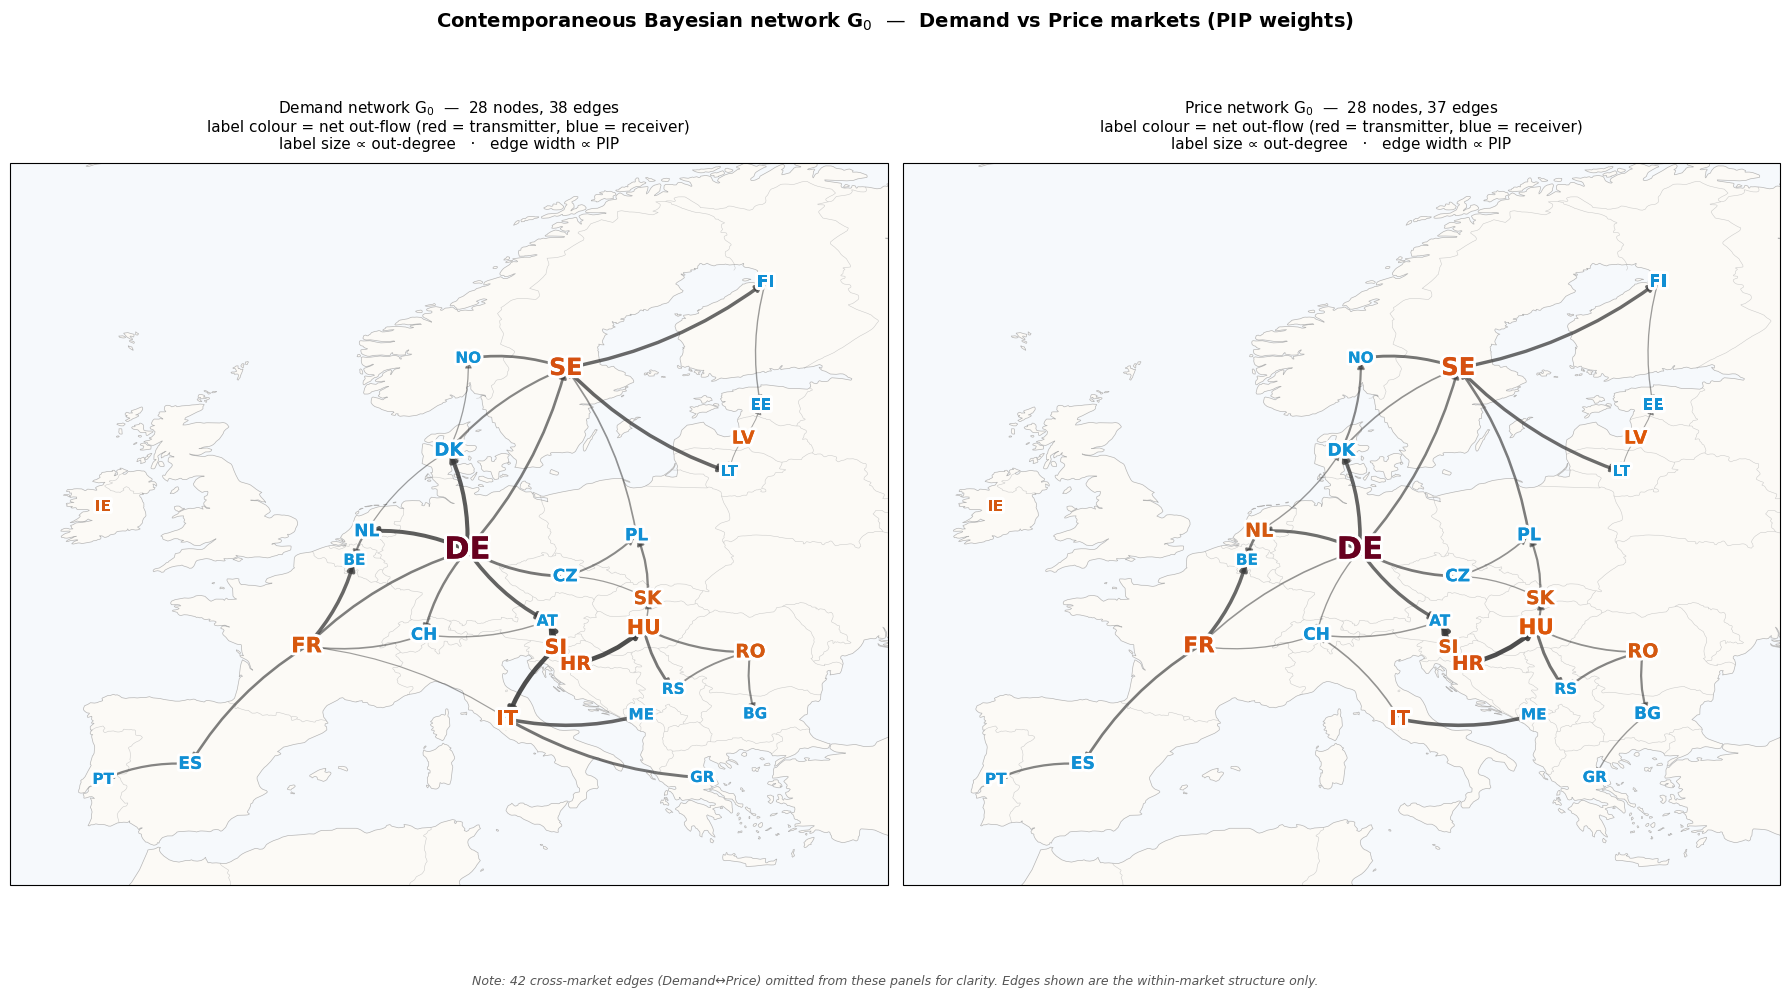

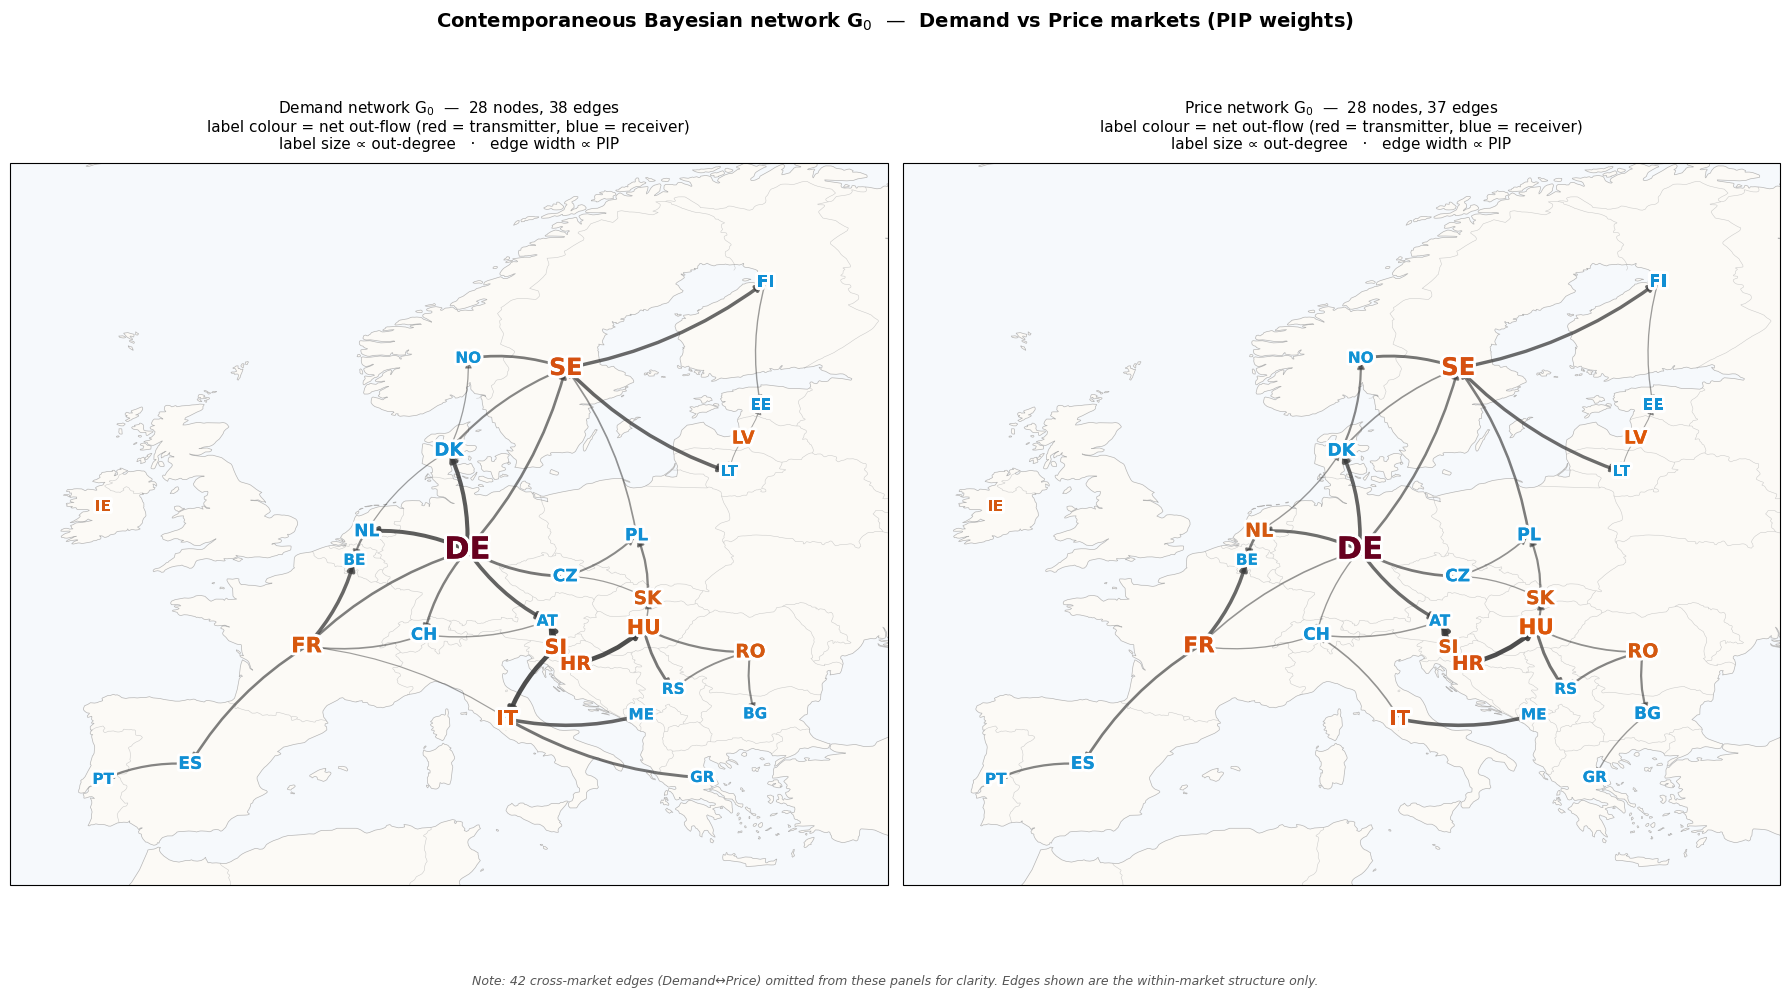

In [18]:
def node_metrics(M_bin, PIP, labels, name):
    """
    Build a directed graph from an MPM adjacency matrix and compute
    in/out-degree, eigenvector centrality, and betweenness centrality.
    Edge weights are set to the PIP (so 'centrality' rewards confident edges).
    """
    G = nx.DiGraph()
    G.add_nodes_from(labels)
    ny = M_bin.shape[0]
    for i in range(ny):
        for j in range(ny):
            if M_bin[i, j] == 1 and i != j:
                # Convention: j -> i  (j drives i)
                G.add_edge(labels[j], labels[i], weight=float(PIP[i, j]))

    # NOTE: in-degree of node X = number of nodes that drive X (X is a receiver)
    #       out-degree of X     = number of nodes X drives (X is a transmitter)
    df = pd.DataFrame({
        "in_degree":   dict(G.in_degree(weight="weight")),
        "out_degree":  dict(G.out_degree(weight="weight")),
        "betweenness": nx.betweenness_centrality(G, weight="weight"),
    })
    try:
        ec = nx.eigenvector_centrality_numpy(G, weight="weight")
        df["eigen"] = pd.Series(ec)
    except Exception:
        df["eigen"] = np.nan

    df["net_flow"] = df["out_degree"] - df["in_degree"]
    df = df.sort_values("out_degree", ascending=False)
    df.to_csv(OUTPUT_DIR / f"node_metrics_{name}.csv")
    return G, df


# --- Contemporaneous network ---
G0_graph, G0_metrics = node_metrics(MPM_G0[0.5], PIP_G0, LABELS, "G0_MPM05")
print("=== G0: top 5 transmitters (highest out-degree) ===")
print(G0_metrics[["out_degree", "in_degree", "net_flow"]].head(5))

print("\n=== G0: top 5 receivers (highest in-degree) ===")
print(G0_metrics.sort_values("in_degree", ascending=False)
      [["in_degree", "out_degree", "net_flow"]].head(5))

print("\n=== G0: top 5 brokers (highest betweenness) ===")
print(G0_metrics.sort_values("betweenness", ascending=False)
      [["betweenness", "out_degree", "in_degree"]].head(5))

# --- Aggregated temporal network: edge active if at any lag MPM is 1 ---
GPhi_any_lag = (MPM_GPhi[0.5].sum(axis=2) > 0).astype(int)
PIP_GPhi_max = PIP_GPhi.max(axis=2)            # max PIP across lags
GPhi_graph, GPhi_metrics = node_metrics(GPhi_any_lag, PIP_GPhi_max,
                                        LABELS, "GPhi_anylag_MPM05")
print("\n=== G_Phi (any lag): top 5 transmitters ===")
print(GPhi_metrics[["out_degree", "in_degree", "net_flow"]].head(5))

# --- Network plot of G0 ---
import importlib, network_plot
importlib.reload(network_plot)
from network_plot import plot_G0_split_geographic, plot_coef_split_geographic

plot_G0_split_geographic(
    G0_graph, G0_metrics,
    top_k=5,
)

# Posterior coefficients of $\Phi$

Coefficient summary:
  Unconditional |Phi| mean:  0.0063
  Conditional   |Phi| mean:  0.0101
  Significant entries (90%): 140 / 12544


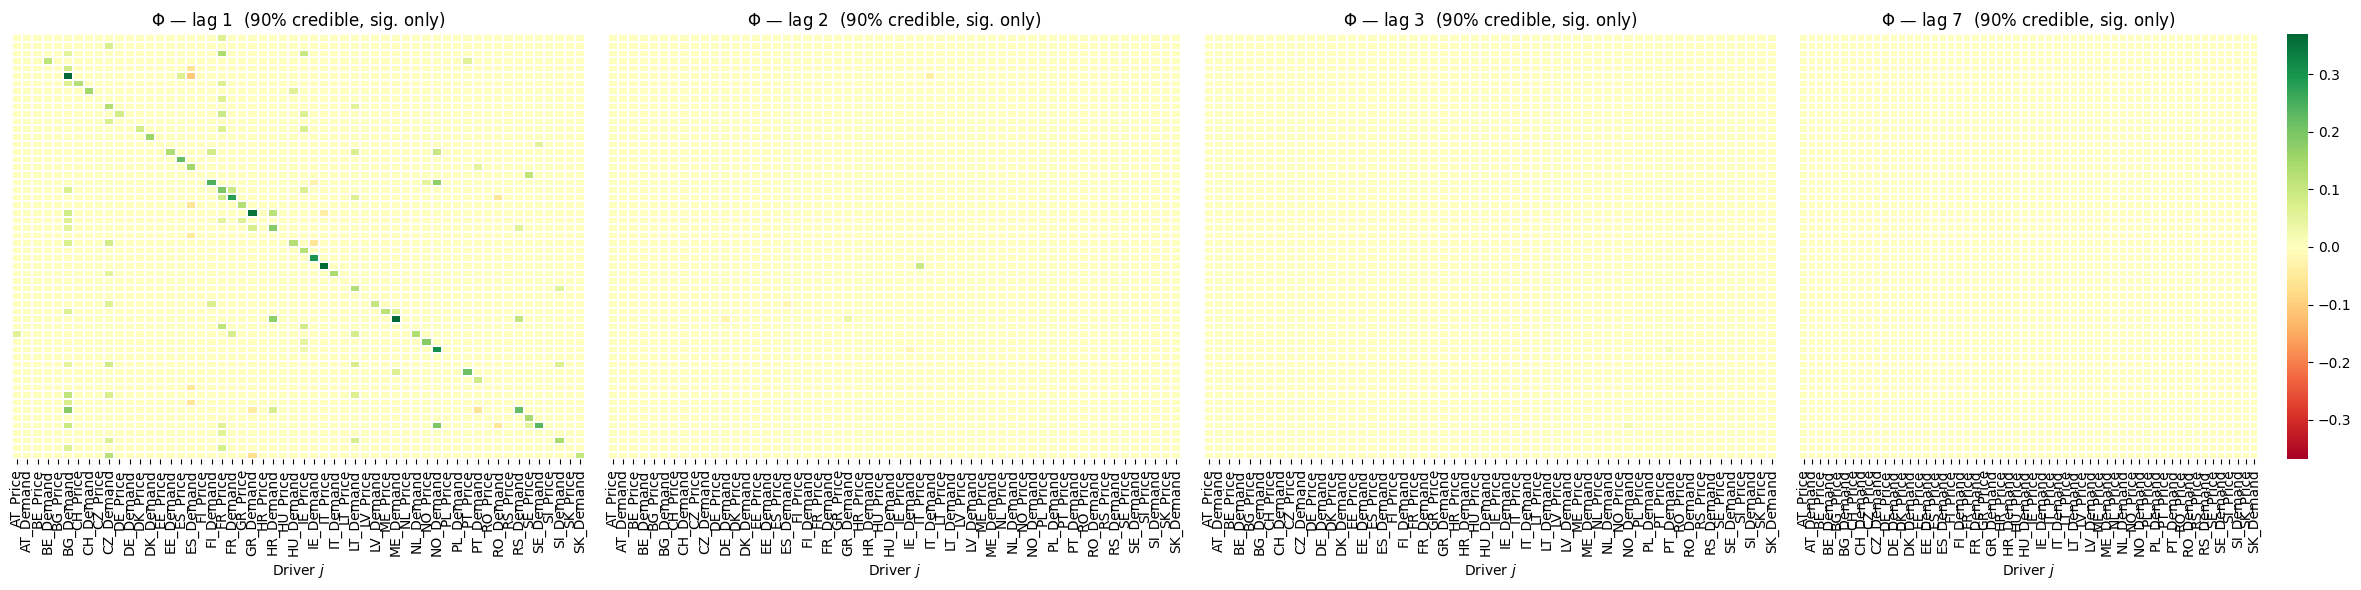


--- Top 20 significant coefficients by magnitude ---
     from        to  lag     coef
ME_Demand ME_Demand    1 0.368875
BG_Demand BG_Demand    1 0.365589
 IT_Price  IT_Price    1 0.360883
GR_Demand GR_Demand    1 0.349124
NO_Demand NO_Demand    1 0.310692
IE_Demand IE_Demand    1 0.299594
FR_Demand FR_Demand    1 0.282249
FI_Demand FI_Demand    1 0.243897
SE_Demand SE_Demand    1 0.235123
 ES_Price  ES_Price    1 0.219399
RS_Demand RS_Demand    1 0.219296
 PT_Price  PT_Price    1 0.213155
NO_Demand SE_Demand    1 0.194972
 FR_Price  FR_Price    1 0.194147
HR_Demand HR_Demand    1 0.182802
 NO_Price  NO_Price    1 0.181914
BG_Demand RS_Demand    1 0.180382
HR_Demand ME_Demand    1 0.174455
NO_Demand FI_Demand    1 0.173417
DK_Demand DK_Demand    1 0.157765


In [20]:
# --- Three complementary summaries ---
# (a) Unconditional posterior mean: averages across all draws (zeros included)
Phi_post_mean = Phi_samp.mean(axis=3)                          # (ny, ny, n_lags)

# (b) Conditional mean: average ONLY over draws where the edge is active
#     This isolates the magnitude of the effect *when it exists*.
mask = GPhi_samp.astype(bool)
n_active = mask.sum(axis=3)                                    # (ny, ny, n_lags)
Phi_cond_sum = np.where(mask, Phi_samp, 0.0).sum(axis=3)
with np.errstate(divide="ignore", invalid="ignore"):
    Phi_cond_mean = np.where(n_active > 0, Phi_cond_sum / n_active, 0.0)

# (c) Significant coefficients: 90% credible interval excludes zero
Phi_q05 = np.quantile(Phi_samp, 0.05, axis=3)
Phi_q95 = np.quantile(Phi_samp, 0.95, axis=3)
sig_mask = (Phi_q05 > 0) | (Phi_q95 < 0)                       # (ny, ny, n_lags)
Phi_signif = np.where(sig_mask, Phi_post_mean, 0.0)

print("Coefficient summary:")
print(f"  Unconditional |Phi| mean:  {np.abs(Phi_post_mean).mean():.4f}")
print(f"  Conditional   |Phi| mean:  {np.abs(Phi_cond_mean).mean():.4f}")
print(f"  Significant entries (90%): {sig_mask.sum()} / {sig_mask.size}")

# --- Heatmap: significant coefficients per lag (red = neg, green = pos) ---
vmax = np.max(np.abs(Phi_signif))
fig, axes = plt.subplots(1, n_lags, figsize=(6 * n_lags, 6), sharey=True)
for l, ax in enumerate(axes):
    sns.heatmap(Phi_signif[:, :, l], cmap="RdYlGn", center=0,
                vmin=-vmax, vmax=vmax,
                xticklabels=LABELS, yticklabels=LABELS if l == 0 else False,
                cbar=(l == n_lags - 1), ax=ax, linewidths=0.2)
    ax.set_title(f"$\\Phi$ — lag {SELECTED_LAGS[l]}  (90% credible, sig. only)")
    ax.set_xlabel("Driver $j$")
plt.tight_layout(); plt.show()

# --- Top coefficients table by magnitude (significant only) ---
def top_coefs(arr, labels, lags, n=20):
    rows = []
    for l, lag in enumerate(lags):
        for i in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                if arr[i, j, l] != 0.0:
                    rows.append({
                        "from": labels[j], "to": labels[i],
                        "lag":  lag,
                        "coef": arr[i, j, l],
                        "abs":  abs(arr[i, j, l]),
                    })
    return (pd.DataFrame(rows).sort_values("abs", ascending=False)
            .drop(columns="abs").head(n).reset_index(drop=True))


print("\n--- Top 20 significant coefficients by magnitude ---")
print(top_coefs(Phi_signif, LABELS, SELECTED_LAGS).to_string(index=False))
top_coefs(Phi_signif, LABELS, SELECTED_LAGS, n=200).to_csv(
    OUTPUT_DIR / "Phi_top_significant.csv", index=False)

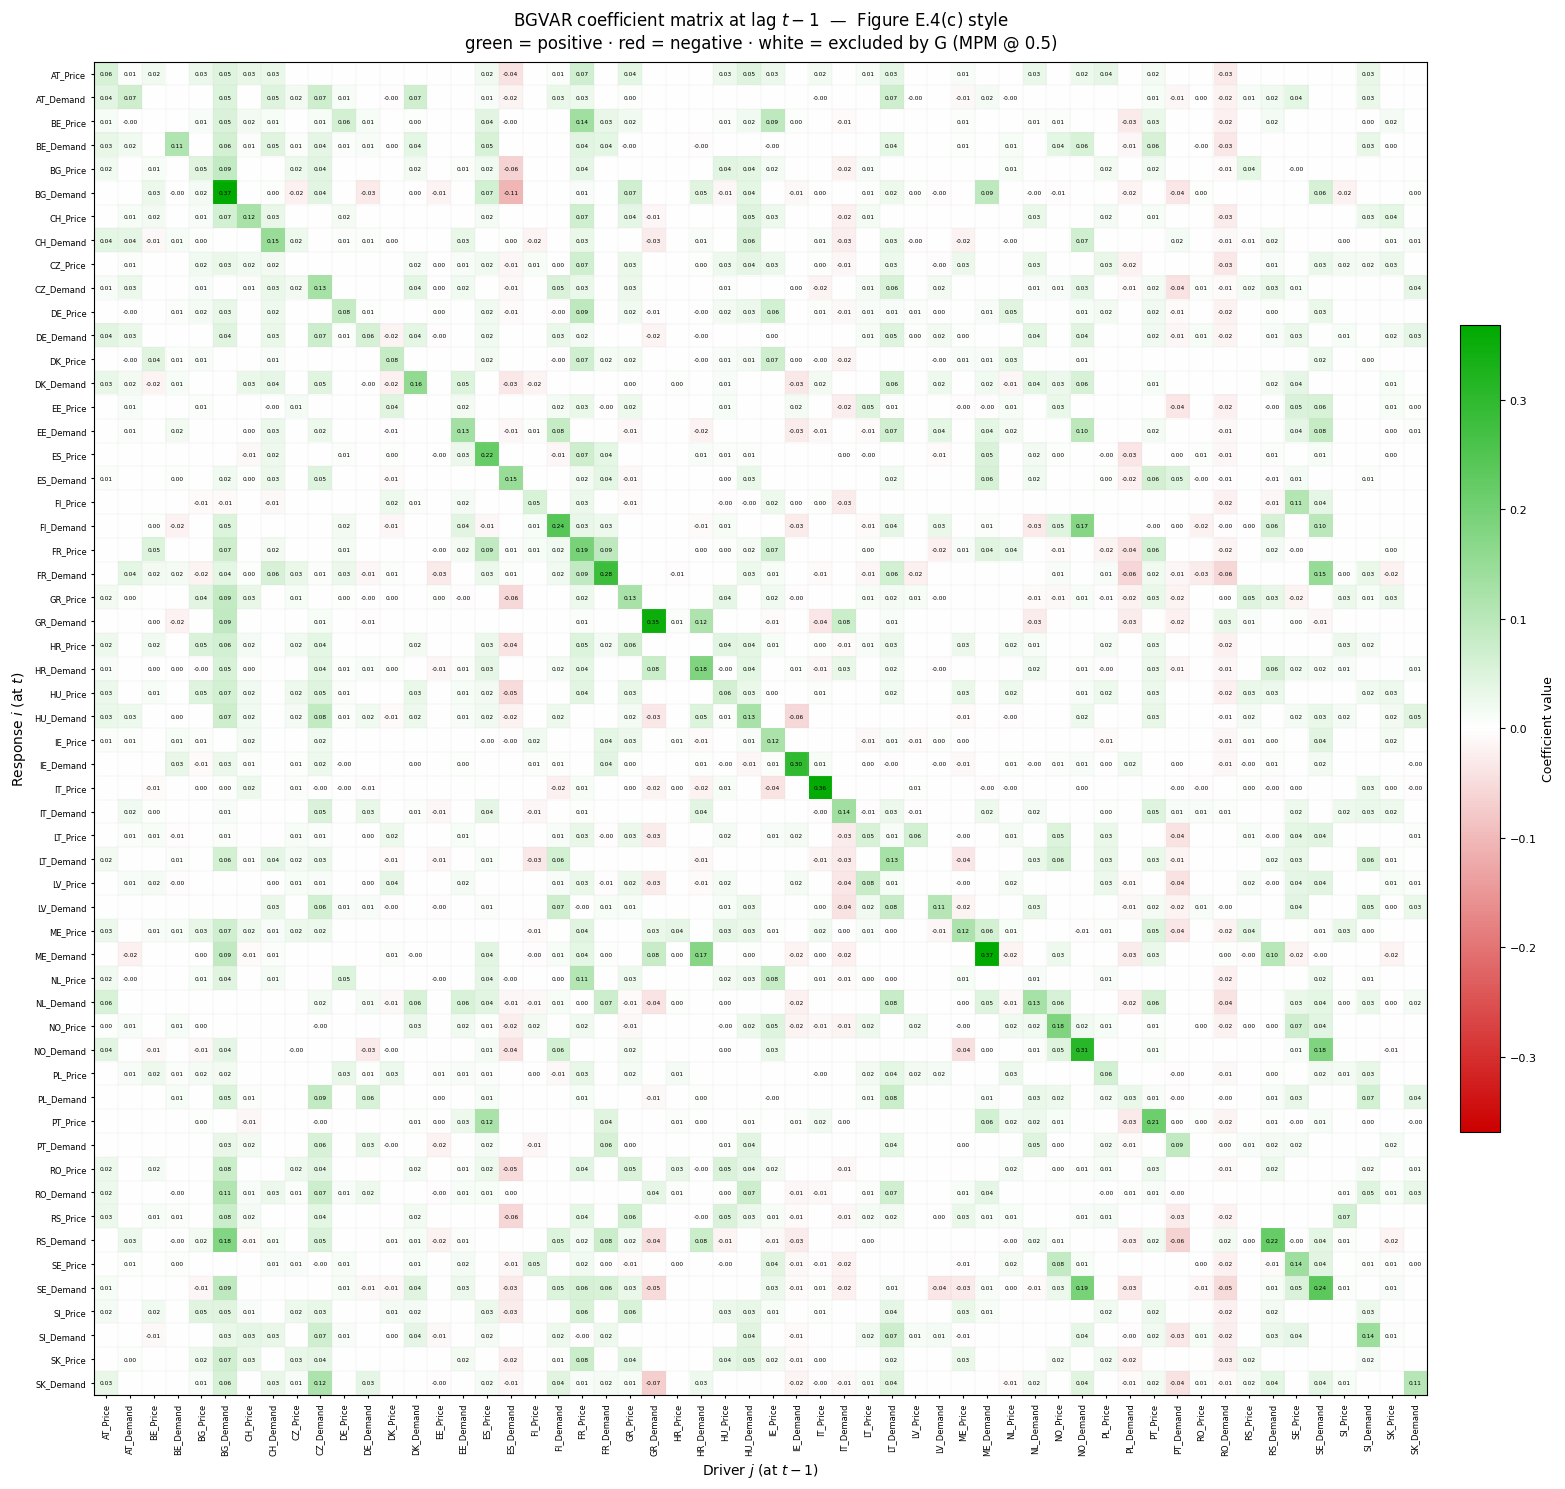

In [9]:
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------------------------------------------------------
# 1. Build the custom red-white-green colormap matching the paper
# -----------------------------------------------------------------------------
# Paper uses pure saturated red/green with sharp white at zero
RWG_COLORS = [
    (0.0, "#cc0000"),   # strong red for most negative
    (0.5, "#ffffff"),   # exact white at zero
    (1.0, "#00aa00"),   # strong green for most positive
]
PAPER_CMAP = LinearSegmentedColormap.from_list("paper_rwg", RWG_COLORS, N=256)


# -----------------------------------------------------------------------------
# 2. Helper to retrieve the posterior mean of Phi at a given lag
#    Adapt the indexing to whatever name your script uses
# -----------------------------------------------------------------------------
def get_phi_at_lag(lag_index):
    """
    Return the (ny, ny) coefficient matrix at the given lag index.
    Tries a few common naming conventions.
    """
    # Try the most likely names in order
    for name in ["Phi_post_mean", "Phi_mean", "PHI_MEAN", "Phi_hat"]:
        if name in globals():
            obj = globals()[name]
            arr = np.asarray(obj)
            # Could be (n_lags, ny, ny) or (ny, ny, n_lags)
            if arr.ndim == 3:
                if arr.shape[0] == len(SELECTED_LAGS):
                    return arr[lag_index]
                elif arr.shape[2] == len(SELECTED_LAGS):
                    return arr[:, :, lag_index]
            elif arr.ndim == 2 and lag_index == 0:
                return arr
    raise NameError(
        "Could not find the posterior mean of Phi. "
        "Please assign your coefficient array to a variable named "
        "'Phi_post_mean' with shape (n_lags, ny, ny) before running this cell."
    )


# -----------------------------------------------------------------------------
# 3. Plot one coefficient matrix in the paper's style
# -----------------------------------------------------------------------------
def plot_bgvar_coef_matrix(
    Phi, mask, labels, lag_label="t-1",
    title=None, ax=None, annotate=True, vmax=None,
):
    """
    Plot a single BGVAR coefficient matrix in the style of Figure E.4(c).

    Parameters
    ----------
    Phi : (ny, ny) array
        Posterior mean coefficients.
    mask : (ny, ny) array of 0/1
        Connectivity mask. Cells where mask==0 are forced to zero (white).
    labels : list of str
        Variable names (length ny).
    lag_label : str
        Suffix for column labels (e.g. 't-1').
    title : str
        Plot title.
    ax : matplotlib axes or None
    annotate : bool
        If True, write the numeric value inside each non-zero cell.
    vmax : float or None
        Symmetric colour limit. If None, computed from data.
    """
    Phi = np.asarray(Phi, dtype=float)
    mask = np.asarray(mask, dtype=int)

    # Apply mask: cells excluded by G become exact zeros (white in the cmap)
    M = np.where(mask == 1, Phi, 0.0)

    # Symmetric colour scale around zero
    if vmax is None:
        vmax = np.nanmax(np.abs(M)) if np.any(M) else 1.0
    vmax = max(vmax, 1e-6)

    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 14))

    im = ax.imshow(
        M, cmap=PAPER_CMAP, vmin=-vmax, vmax=vmax,
        aspect="equal", interpolation="nearest",
    )

    # Tick labels: rows = response (i,t), cols = driver (j, t-lag)
    ny = M.shape[0]
    ax.set_xticks(np.arange(ny))
    ax.set_yticks(np.arange(ny))
    ax.set_xticklabels(labels, rotation=90, fontsize=6)
    ax.set_yticklabels(labels, fontsize=6)

    # Light grid between cells, like the paper's dotted separators
    ax.set_xticks(np.arange(-0.5, ny, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ny, 1), minor=True)
    ax.grid(which="minor", color="#cccccc", linewidth=0.3, linestyle=":")
    ax.tick_params(which="minor", length=0)
    ax.tick_params(which="major", length=2)

    # Numeric annotations inside non-zero cells
    if annotate:
        for i in range(ny):
            for j in range(ny):
                v = M[i, j]
                if v == 0.0:
                    continue
                # Choose readable text colour against background
                # (red/green are dark enough that white text reads well
                # only on saturated cells; we use small black text instead,
                # matching the paper's style of small dark numbers)
                ax.text(
                    j, i, f"{v:.2f}",
                    ha="center", va="center",
                    fontsize=4.2, color="black",
                )

    if title:
        ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(f"Driver $j$ (at $t-{lag_label.replace('t-', '')}$)",
                  fontsize=10)
    ax.set_ylabel("Response $i$ (at $t$)", fontsize=10)

    # Colour bar
    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Coefficient value", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    return ax


# =============================================================================
# 4. MAIN CALL — plot coefficient matrix at lag 1 (the one with structure)
# =============================================================================

# The paper plots only lag t-1 in Figure E.4(c) since their model has p=1.
# Your model has multiple lags but only lag 1 carries meaningful information,
# so we replicate that single panel here.
LAG_TO_PLOT = 0  # index into SELECTED_LAGS; 0 corresponds to lag 1

Phi_lag = get_phi_at_lag(LAG_TO_PLOT)
mask_lag = MPM_GPhi[0.5][:, :, LAG_TO_PLOT]

fig, ax = plt.subplots(figsize=(17, 15))
plot_bgvar_coef_matrix(
    Phi_lag, mask_lag, LABELS,
    lag_label=f"t-{SELECTED_LAGS[LAG_TO_PLOT]}",
    title=(
        f"BGVAR coefficient matrix at lag "
        f"$t-{SELECTED_LAGS[LAG_TO_PLOT]}$  —  Figure E.4(c) style\n"
        f"green = positive · red = negative · white = excluded by G "
        f"(MPM @ 0.5)"
    ),
    ax=ax,
    annotate=True,
)
plt.tight_layout()

# Optional save:
# plt.savefig(OUTPUT_DIR / "BGVAR_coef_matrix_lag1.png", dpi=300,
#             bbox_inches="tight")

plt.show()


# =============================================================================
# 5. (Optional) Multi-panel version: one coefficient matrix per selected lag
# =============================================================================
# Uncomment the block below to plot all selected lags side-by-side.
#
# n_lags = len(SELECTED_LAGS)
# fig, axes = plt.subplots(1, n_lags, figsize=(14 * n_lags, 13))
# if n_lags == 1:
#     axes = [axes]
#
# # Use a common vmax across panels for fair colour comparison
# vmax_global = max(
#     np.nanmax(np.abs(get_phi_at_lag(l) * MPM_GPhi[0.5][:, :, l]))
#     for l in range(n_lags)
# )
#
# for l, ax in enumerate(axes):
#     plot_bgvar_coef_matrix(
#         get_phi_at_lag(l),
#         MPM_GPhi[0.5][:, :, l],
#         LABELS,
#         lag_label=f"t-{SELECTED_LAGS[l]}",
#         title=f"Lag $t-{SELECTED_LAGS[l]}$",
#         ax=ax,
#         annotate=(l == 0),     # annotate only the first (densest) panel
#         vmax=vmax_global,
#     )
# plt.tight_layout()
# plt.show()

# Residual correlations

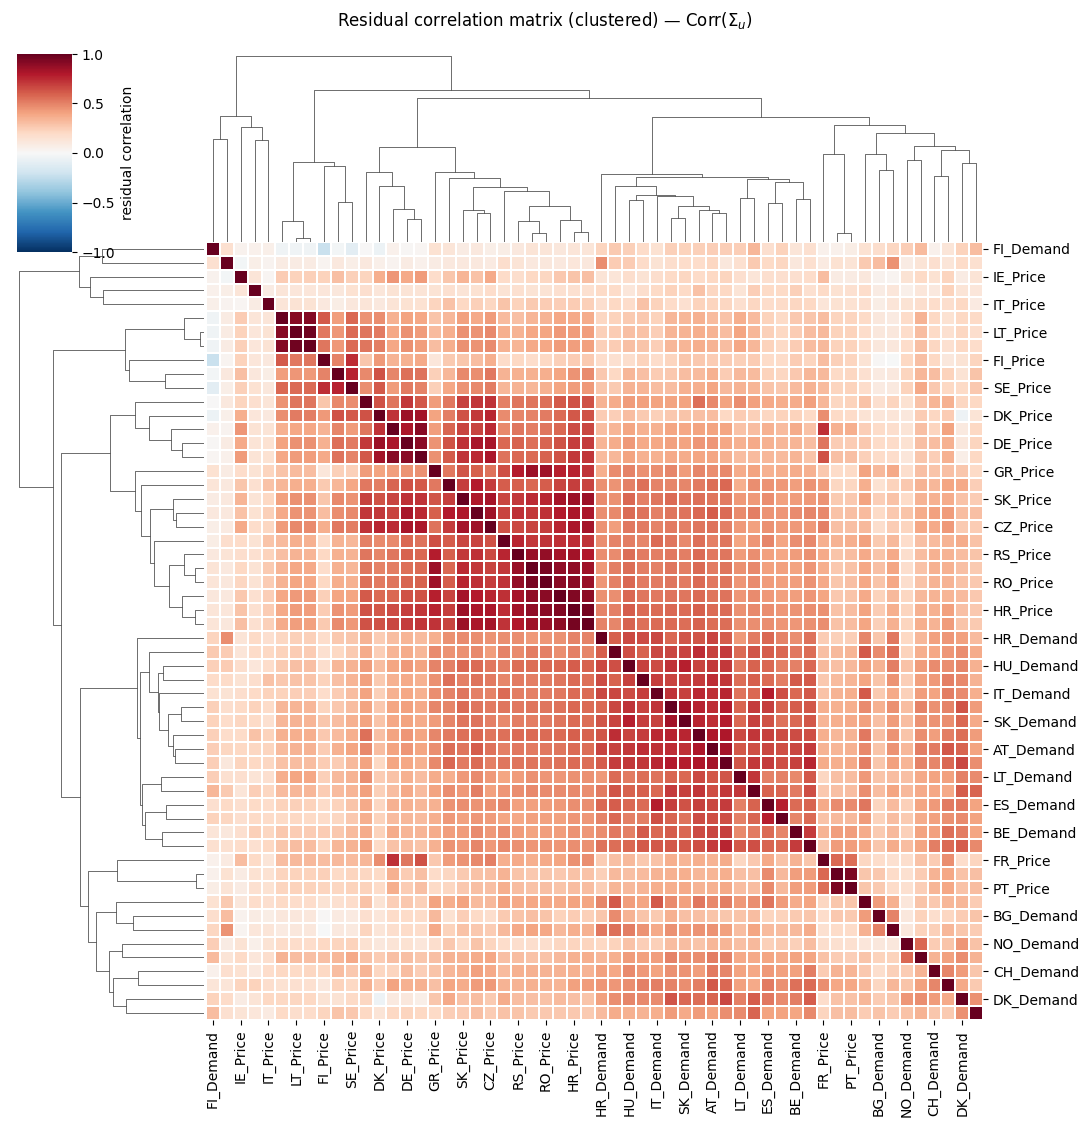

--- Top 15 residual correlations (after structural model) ---
   var_i    var_j  residual_corr
LT_Price LV_Price       0.969286
HR_Price SI_Price       0.956247
BG_Price RO_Price       0.951890
ES_Price PT_Price       0.943845
HR_Price HU_Price       0.922524
EE_Price LV_Price       0.915216
BE_Price NL_Price       0.913225
EE_Price LT_Price       0.909134
HU_Price RO_Price       0.904430
HR_Price RO_Price       0.902770
DE_Price NL_Price       0.901958
HU_Price SI_Price       0.890776
BG_Price HU_Price       0.890030
BG_Price HR_Price       0.886951
RO_Price RS_Price       0.877168


In [ ]:
# --- Posterior median of Sigma_u (more robust than mean for covariances) ---
Sigma_post = np.median(Sigma_samp, axis=2)
D          = np.sqrt(np.diag(Sigma_post))
Corr_u     = Sigma_post / np.outer(D, D)

# --- Clustermap reveals geographical / variable-type blocks ---
g = sns.clustermap(pd.DataFrame(Corr_u, index=LABELS, columns=LABELS),
                   cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                   figsize=(11, 11), linewidths=0.2,
                   cbar_kws={"label": "residual correlation"})
g.fig.suptitle("Residual correlation matrix (clustered) — Corr($\\Sigma_u$)",
               y=1.02)
plt.show()

# --- High residual correlations report ---
upper = np.triu_indices(ny, k=1)
corr_pairs = pd.DataFrame({
    "var_i":     [LABELS[i] for i in upper[0]],
    "var_j":     [LABELS[j] for j in upper[1]],
    "residual_corr": Corr_u[upper],
})
corr_pairs["abs"] = corr_pairs["residual_corr"].abs()
print("--- Top 15 residual correlations (after structural model) ---")
print(corr_pairs.sort_values("abs", ascending=False)
      .head(15).drop(columns="abs").to_string(index=False))